# Laboratorio 3 - Tuneo de hiperparámetros

- Mathew Cordero 22982
- Pedro Guzmán 22111

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
# Transformaciones: convierte a tensor y normaliza
transform = transforms.Compose([
    transforms.ToTensor(),  # Convierte PIL image a Tensor
    transforms.Normalize((0.1307,), (0.3081,))  # Normaliza con media y std de MNIST
])

# Cargar conjunto de entrenamiento
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)

train_size = int(0.8 * len(train_dataset))  # 80% entrenamiento
val_size = len(train_dataset) - train_size  # 20% validación

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Cargar conjunto de prueba
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)





## Primera red

In [15]:
class classifier(nn.Module):
    def __init__(self, net_structure):
        super(classifier, self).__init__()
        self.model = net_structure
        
    def forward(self, x):
        return self.model(x)

net_structure = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.Sigmoid(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

model = classifier(net_structure)

Función de entrenaminento.

In [16]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20
train_losses = []
val_losses = []

def train(model):

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")
        train_losses.append(running_loss/len(train_loader))

        model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = loss_function(outputs, labels)
                running_loss += loss.item()
            val_losses.append(running_loss/len(val_loader))

In [17]:
import matplotlib.pyplot as plt

train(model)

Epoch [1/20], Loss: 0.3675
Epoch [2/20], Loss: 0.1440
Epoch [3/20], Loss: 0.0926
Epoch [4/20], Loss: 0.0660
Epoch [5/20], Loss: 0.0476
Epoch [6/20], Loss: 0.0348
Epoch [7/20], Loss: 0.0257
Epoch [8/20], Loss: 0.0220
Epoch [9/20], Loss: 0.0167
Epoch [10/20], Loss: 0.0152
Epoch [11/20], Loss: 0.0135
Epoch [12/20], Loss: 0.0099
Epoch [13/20], Loss: 0.0097
Epoch [14/20], Loss: 0.0128
Epoch [15/20], Loss: 0.0084
Epoch [16/20], Loss: 0.0105
Epoch [17/20], Loss: 0.0084
Epoch [18/20], Loss: 0.0109
Epoch [19/20], Loss: 0.0041
Epoch [20/20], Loss: 0.0089


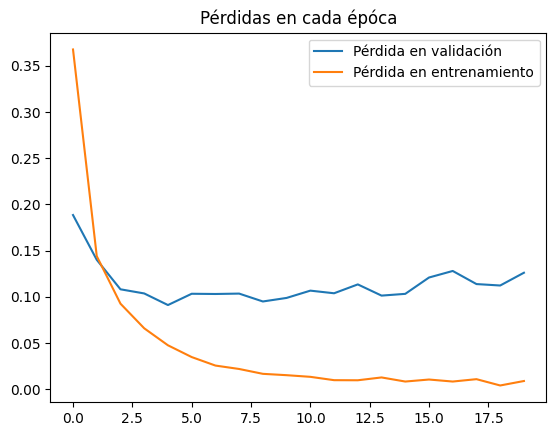

In [ ]:
import matplotlib.pyplot as plt

def graph_comparative(val_losses, train_losses):
    
    plt.figure()
    plt.plot(val_losses, label = "Pérdida en validación")
    plt.plot(train_losses, label = "Pérdida en entrenamiento")
    plt.legend()
    plt.title("Pérdidas en cada épóca")
    plt.show()
